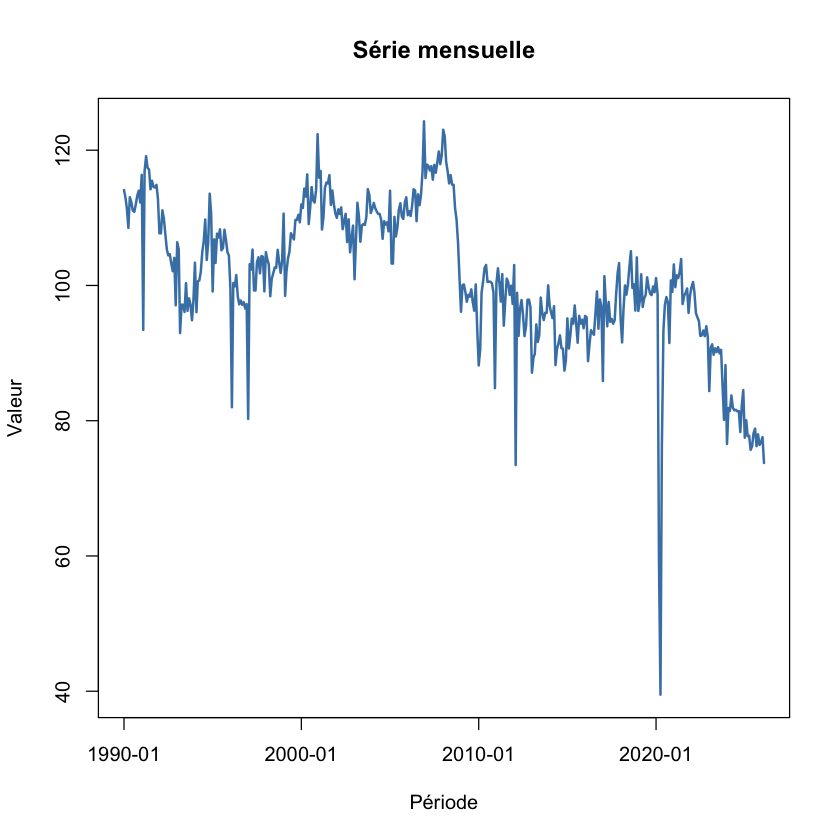

In [1]:
df <- read.csv2("valeurs_mensuelles.csv", header = FALSE, stringsAsFactors = FALSE, fileEncoding = "UTF-8-BOM")

series <- df[grepl("^\\d{4}-\\d{2}$", df[[1]]), c(1, 2)]
names(series) <- c("periode", "valeur")

series$periode <- as.Date(paste0(series$periode, "-01"))
series$valeur <- as.numeric(gsub(",", ".", series$valeur, fixed = TRUE))
series <- series[order(series$periode), ]

plot(
    series$periode,
    series$valeur,
    type = "l",
    col = "steelblue",
    lwd = 2,
    xlab = "Période",
    ylab = "Valeur",
    main = "Série mensuelle",
    xaxt = "n"
 )
axis.Date(1, at = pretty(series$periode), format = "%Y-%m")

Notre étude porte sur la série temporelle mensuelle de l'Indice de la Production Industrielle (IPI), spécifiquement pour le secteur des "Autres industries extractives" en France métropolitaine, sur la période allant de janvier 1990 à février 2026. L'indice est calculé en base 100 sur l'année de référence 2021 et est corrigé des variations saisonnières ainsi que du nombre de jours ouvrables (CVS-CJO).L'ensemble des observations de notre série sont certifiées comme des valeurs normales et définitives par l'institut émetteur.

Nature de l'activité étudiée
Selon la nomenclature officielle de l'Institut National de la Statistique et des Études Économiques (INSEE), la division 08 ("Autres industries extractives" de la NAF rév. 2) exclut l'extraction d'hydrocarbures et de minerais métalliques. En France, ce secteur regroupe principalement :

- L'extraction et le dragage de sables.

- La production de graviers, roches concassées et galets.

- L'extraction de pierres de construction, d'argiles et de kaolin.

Ces matériaux, couramment appelés "granulats", constituent la matière première fondamentale pour la fabrication du béton et la réalisation de chantiers. Par conséquent, la production de cette industrie est directement dictée par la demande locale. Cette série temporelle agit donc comme un excellent indicateur coïncident de la santé du secteur du Bâtiment et des Travaux Publics (BTP) français.

2. Analyse visuelle et interprétation des grandes tendances
L'inspection visuelle de la série permet d'identifier plusieurs cycles macroéconomiques et ruptures structurelles qui reflètent fidèlement l'histoire de la construction en France :

1990 - 2008 : La phase d'expansion. Après une décennie de stabilité relative dans les années 1990, la série entame une forte tendance haussière tout au long des années 2000. Cette période correspond à un cycle exceptionnel de croissance de l'immobilier en France, tirant la demande en matériaux vers des sommets historiques (avec un indice dépassant régulièrement les 115).

2008 - 2009 : Le choc financier. La série enregistre une chute abrupte de la production. Ce point de rupture majeur coïncide avec la crise financière mondiale des subprimes, qui a entraîné un assèchement brutal du crédit et un coup d'arrêt immédiat pour le marché immobilier et les chantiers.

2010 - 2019 : Une longue stagnation. Durant cette décennie, la tendance globale de la série est légèrement décroissante. Le secteur du BTP peine à retrouver son dynamisme d'avant-crise et la production de granulats s'installe sur un plateau inférieur (fluctuant entre un indice de 90 et 100).

Avril 2020 : Le krach pandémique. La série présente un point aberrant extrême, avec un effondrement spectaculaire de l'indice à 39.49. Ce cratère d'activité s'explique directement par le premier confinement national lié à la crise sanitaire du Covid-19, qui a mis à l'arrêt quasi total la production et les chantiers sur tout le territoire.

2023 - 2026 : Une nouvelle crise structurelle. La fin de la série est marquée par une tendance de nouveau fortement décroissante, l'indice tombant sous la barre des 80. Cette baisse reflète l'entrée en crise brutale du secteur du logement neuf. L'activité d'extraction des matériaux de construction (comme les granulats et le béton) subit une chute importante, pénalisée par un contexte économique très défavorable : même si l'on note récemment une amorce de baisse des taux d'intérêt, l'inflation persistante et la paralysie des permis de construire continuent de peser lourdement sur la production nationale.

===== 2.2 TEST ADF (PROCEDURE RIGOUREUSE EN 3 MODELES) =====

--- ADF sur serie en niveau ---
Modele final retenu: trend 
Lag ADF (AIC): 12 
Statistique tau (ylag1): -2.384 
Valeur critique 5%: -3.41 
Decision: Non-rejet H0 (racine unitaire, non stationnaire) 
p-value tendance (modele trend): 0.04494 


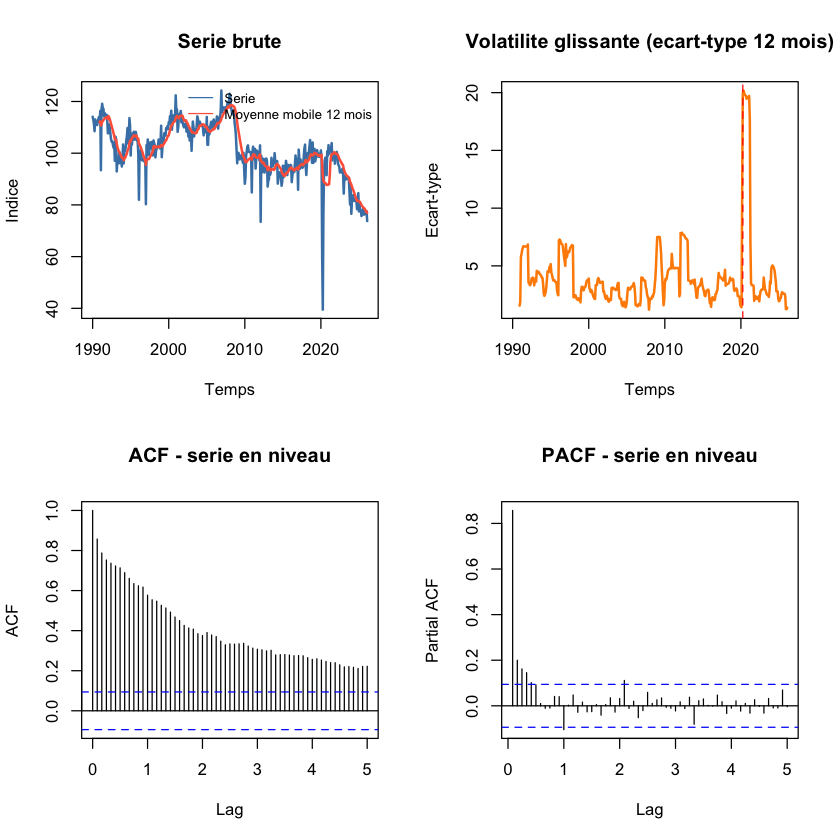


--- ADF sur serie differenciee ---
Modele final retenu: none 
Lag ADF (AIC): 12 
Statistique tau (ylag1): -7.1351 
Valeur critique 5%: -1.95 
Decision: Rejet H0 (stationnaire) 
p-value tendance (modele trend): 0.3426 
p-value constante (modele drift): 0.4041 

===== 2.4 INTERPRETATION ACF / PACF =====
- En niveau: si l'ACF decroit lentement, cela confirme la non-stationnarite.
- En difference: si l'ACF/PACF coupent plus vite, la stationnarite est plausible.

===== CONCLUSION GLOBALE =====
La serie semble I(1): non stationnaire en niveau, stationnaire apres 1 difference.

Note: seuils critiques utilises (none=-1.95, drift=-2.86, trend=-3.41) sont des approximations asymptotiques a 5%.


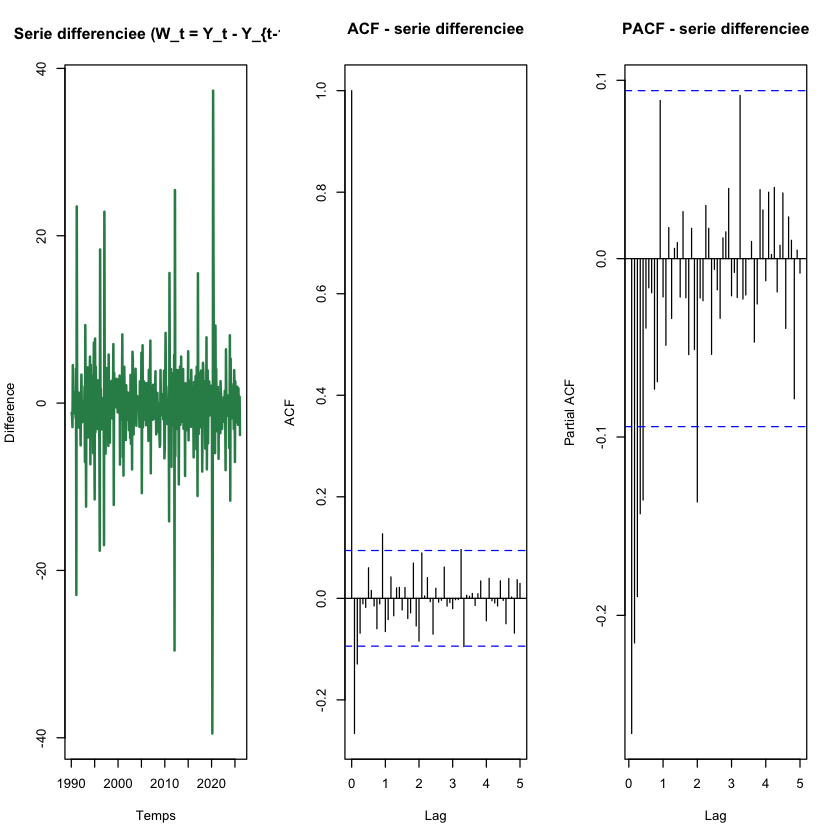

In [4]:
# 2.1 Analyse visuelle et premieres intuitions
start_year <- as.integer(format(min(series$periode), "%Y"))
start_month <- as.integer(format(min(series$periode), "%m"))
y <- ts(series$valeur, start = c(start_year, start_month), frequency = 12)

roll_n <- 12
roll_mean <- stats::filter(as.numeric(y), rep(1 / roll_n, roll_n), sides = 1)
roll_sd <- sapply(seq_along(y), function(i) {
  if (i < roll_n) return(NA_real_)
  sd(as.numeric(y)[(i - roll_n + 1):i], na.rm = TRUE)
})

op <- par(no.readonly = TRUE)
par(mfrow = c(2, 2))
plot(y, type = "l", col = "steelblue", lwd = 2,
     main = "Serie brute", xlab = "Temps", ylab = "Indice")
lines(ts(roll_mean, start = start(y), frequency = 12), col = "tomato", lwd = 2)
legend("topright", legend = c("Serie", "Moyenne mobile 12 mois"),
       col = c("steelblue", "tomato"), lty = 1, bty = "n", cex = 0.8)

plot(ts(roll_sd, start = start(y), frequency = 12), type = "l", col = "darkorange", lwd = 2,
     main = "Volatilite glissante (ecart-type 12 mois)", xlab = "Temps", ylab = "Ecart-type")
abline(v = 2020 + 3/12, col = "red", lty = 2)

acf(y, lag.max = 60, main = "ACF - serie en niveau")
pacf(y, lag.max = 60, main = "PACF - serie en niveau")
par(op)

cat("===== 2.2 TEST ADF (PROCEDURE RIGOUREUSE EN 3 MODELES) =====\n")

# Outils ADF sans package externe (approximation asymptotique des seuils a 5%)
make_adf_data <- function(x, k) {
  dx <- diff(as.numeric(x))
  df <- data.frame(
    dy = dx,
    ylag1 = as.numeric(x)[1:(length(x) - 1)],
    t = seq_along(dx)
  )
  if (k > 0) {
    for (i in 1:k) {
      lag_vec <- c(rep(NA_real_, i), dx[1:(length(dx) - i)])
      df[[paste0("dylag", i)]] <- lag_vec
    }
  }
  stats::na.omit(df)
}

fit_adf_type_k <- function(x, type = c("trend", "drift", "none"), k = 0) {
  type <- match.arg(type)
  df <- make_adf_data(x, k)
  lag_names <- if (k > 0) paste0("dylag", 1:k) else character(0)
  if (type == "trend") {
    terms <- c("ylag1", "t", lag_names)
    fml <- as.formula(paste("dy ~", paste(terms, collapse = " + ")))
  } else if (type == "drift") {
    terms <- c("ylag1", lag_names)
    fml <- as.formula(paste("dy ~", paste(terms, collapse = " + ")))
  } else {
    terms <- c("ylag1", lag_names)
    fml <- as.formula(paste("dy ~", paste(terms, collapse = " + "), "- 1"))
  }
  fit <- lm(fml, data = df)
  sm <- summary(fit)
  co <- sm$coefficients
  t_gamma <- co["ylag1", "t value"]
  p_trend <- if (type == "trend") co["t", "Pr(>|t|)"] else NA_real_
  p_const <- if (type %in% c("trend", "drift")) co["(Intercept)", "Pr(>|t|)"] else NA_real_
  crit_5 <- switch(type, none = -1.95, drift = -2.86, trend = -3.41)
  list(
    type = type,
    k = k,
    fit = fit,
    t_gamma = unname(t_gamma),
    crit_5 = crit_5,
    reject_unit_root_5pct = (t_gamma < crit_5),
    p_trend = unname(p_trend),
    p_const = unname(p_const),
    aic = AIC(fit)
  )
}

select_adf_by_aic <- function(x, type = c("trend", "drift", "none"), k_max = 12) {
  type <- match.arg(type)
  cands <- lapply(0:k_max, function(k) fit_adf_type_k(x, type = type, k = k))
  aics <- sapply(cands, function(z) z$aic)
  cands[[which.min(aics)]]
}

choose_deterministic_terms <- function(x, k_max = 12) {
  m_trend <- select_adf_by_aic(x, "trend", k_max = k_max)
  if (!is.na(m_trend$p_trend) && m_trend$p_trend < 0.05) {
    decision <- "trend"
    final_model <- m_trend
    m_drift <- NULL
  } else {
    m_drift <- select_adf_by_aic(x, "drift", k_max = k_max)
    if (!is.na(m_drift$p_const) && m_drift$p_const < 0.05) {
      decision <- "drift"
      final_model <- m_drift
    } else {
      decision <- "none"
      final_model <- select_adf_by_aic(x, "none", k_max = k_max)
    }
  }
  list(m_trend = m_trend, m_drift = m_drift, final = final_model, decision = decision)
}

report_adf <- function(lbl, out) {
  cat("\n---", lbl, "---\n")
  cat("Modele final retenu:", out$decision, "\n")
  cat("Lag ADF (AIC):", out$final$k, "\n")
  cat("Statistique tau (ylag1):", round(out$final$t_gamma, 4), "\n")
  cat("Valeur critique 5%:", out$final$crit_5, "\n")
  cat("Decision:", ifelse(out$final$reject_unit_root_5pct,
                         "Rejet H0 (stationnaire)",
                         "Non-rejet H0 (racine unitaire, non stationnaire)"), "\n")
  if (!is.null(out$m_trend)) {
    cat("p-value tendance (modele trend):", signif(out$m_trend$p_trend, 4), "\n")
  }
  if (!is.null(out$m_drift)) {
    cat("p-value constante (modele drift):", signif(out$m_drift$p_const, 4), "\n")
  }
}

# Niveau
adf_level <- choose_deterministic_terms(y, k_max = 12)
report_adf("ADF sur serie en niveau", adf_level)

# 2.3 Differenciation
dy <- diff(y)

op <- par(no.readonly = TRUE)
par(mfrow = c(1, 3))
plot(dy, type = "l", col = "seagreen4", lwd = 2,
     main = "Serie differenciee (W_t = Y_t - Y_{t-1})", xlab = "Temps", ylab = "Difference")
acf(dy, lag.max = 60, main = "ACF - serie differenciee")
pacf(dy, lag.max = 60, main = "PACF - serie differenciee")
par(op)

adf_diff <- choose_deterministic_terms(dy, k_max = 12)
report_adf("ADF sur serie differenciee", adf_diff)

cat("\n===== 2.4 INTERPRETATION ACF / PACF =====\n")
cat("- En niveau: si l'ACF decroit lentement, cela confirme la non-stationnarite.\n")
cat("- En difference: si l'ACF/PACF coupent plus vite, la stationnarite est plausible.\n")

cat("\n===== CONCLUSION GLOBALE =====\n")
if (!adf_level$final$reject_unit_root_5pct && adf_diff$final$reject_unit_root_5pct) {
  cat("La serie semble I(1): non stationnaire en niveau, stationnaire apres 1 difference.\n")
} else if (adf_level$final$reject_unit_root_5pct) {
  cat("La serie semble deja stationnaire en niveau selon la regle ADF retenue.\n")
} else {
  cat("La non-stationnarite persiste apres 1 difference; envisager rupture structurelle ou transformations supplementaires.\n")
}

cat("\nNote: seuils critiques utilises (none=-1.95, drift=-2.86, trend=-3.41) sont des approximations asymptotiques a 5%.\n")